# Madroño — demo del asistente conversacional

**Hablas con los datos abiertos de Madrid en lenguaje natural y te responde
apoyándose *solo* en lo que devuelven sus herramientas — con procedencia
trazable.**

Este cuaderno recorre la **capa LLM + MCP** del sistema en ~4 minutos:

| § | Qué demuestra | Necesita |
|---|---|---|
| 1 | El servidor **MCP** real: 19 tools de solo lectura + el catálogo del chat | nada |
| 2 | Una tool por dentro — el envoltorio `{disponible, motivo, datos}` | nada *(datos mock)* |
| 3 | El **bucle de tool-calling** y la traza **`pasos`** (FIL_95) que ve el usuario | nada *(LLM con guion; real si hay `LLM_API_KEY`)* |
| 4 | **`ruta_saludable`** — la ruta que cambia metros por aire limpio | nada *(artefacto vendorizado)* |
| 5 | **Degradación elegante** — el asistente dice «no lo sé», no se lo inventa | nada |
| 6 | Cómo lo ve el usuario (landing + mapa) y dónde probarlo en vivo | nada |

> Corre **sin credenciales**: Athena/Neo4j se sustituyen por datos de demo y
> el LLM por un guion determinista que ejerce *el mismo bucle real*. Con
> `LLM_API_KEY`/`GROQ_API_KEY` en el entorno, §3 llama al modelo de verdad.


## Guion para la defensa / screencast (~6 min con la app en vivo)

1. **(30 s)** Abre la **landing** (`web/index.html` desplegada) — login demo.
   Pulsa **«? Qué puedo preguntar»**: el catálogo sale del *registro único*
   de tools (§1), no de una lista a mano.
2. **(60 s)** Pregunta *«¿Cómo está el aire en Retiro y me conviene salir a
   correr?»*. Cuando responda, señala la línea **`calidad_aire · …`**
   bajo la respuesta: son las herramientas que ejecutó *este* turno (§3).
3. **(60 s)** Pregunta *«Dame una ruta saludable de Sol a Atocha para
   alguien con asma»*. Enseña que compara **sana vs rápida** y da la
   **mejor hora de salida** (§4).
4. **(45 s)** Pregunta *«ruta de Vallecas a Chamberí»*. No se la inventa:
   dice que no es un punto de referencia y ofrece los 17 válidos (§5).
5. **(90 s)** Abre el **mapa animado** (`/mapa` o GitHub Pages) y el
   **explorador de grafo** en vivo — el mismo asistente en el panel lateral,
   sobre el grafo real de ~9.600 nodos.
6. **(30 s)** Cierra con §7.4: ventana de datos corta, `fiabilidad` topada,
   pipeline congelado. Nada maquillado.

El resto del cuaderno es la versión *ejecutable* de los puntos 1–5.


In [1]:
import os, sys, json, time, logging
from pathlib import Path
from datetime import datetime, timedelta
from unittest.mock import patch

ROOT = Path.cwd()
if not (ROOT / "asistente").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
logging.disable(logging.WARNING)

TIENE_LLM = bool(os.environ.get("LLM_API_KEY") or os.environ.get("GROQ_API_KEY"))
MOMENTO = datetime(2026, 8, 29, 18, 0)   # dentro de la ventana con datos reales

print("repo:", ROOT)
print("LLM real disponible:" , "SÍ (se usará en §3)" if TIENE_LLM else "no — §3 usa un guion determinista")
print("pipeline de ingesta CONGELADO desde 2026-08-30 — los datos llegan hasta ~2026-08-29")


repo: C:\Users\dorez\madrono
LLM real disponible: no — §3 usa un guion determinista
pipeline de ingesta CONGELADO desde 2026-08-30 — los datos llegan hasta ~2026-08-29


## 1 · El servidor MCP y el catálogo del chat

Las herramientas se declaran **una sola vez** en `asistente/mcp_agent/server.py`
(`_TOOLS`, tuplas `ToolSpec`). De ahí salen: el servidor MCP, los routers
HTTP, la tabla de los README, el `tools=[…]` del chat y el catálogo
`GET /chat/catalogo` que ve el usuario. Añadir una tool = una línea.


In [2]:
from asistente.mcp_agent.server import TOOLS, NOMBRES_CHAT, CATALOGO_CHAT, mcp

print(f"{len(TOOLS)} herramientas registradas; {len(NOMBRES_CHAT)} ofrecidas al LLM del chat\n")
for s in TOOLS:
    marca = "chat" if s.fn.__name__ in NOMBRES_CHAT else "  · "
    print(f"  [{marca}] {s.fn.__name__:28} {s.titulo}")

print("\nCatálogo «¿qué puedo preguntar?» (GET /chat/catalogo) — una entrada por tool del chat:")
for e in CATALOGO_CHAT:
    print(f'  · {e["titulo"]:38} → "{e["ejemplo"]}"')


19 herramientas registradas; 11 ofrecidas al LLM del chat

  [  · ] afluencia_estimada           Afluencia estimada ahora
  [  · ] afluencia_prevista           Afluencia prevista
  [chat] calidad_aire                 Calidad del aire ahora
  [  · ] calidad_aire_prevista        Calidad del aire prevista
  [  · ] calidad_aire_prevista_grafo  Calidad del aire prevista (modelo de grafo)
  [chat] calidad_aire_episodio        Probabilidad de episodio de contaminación
  [  · ] calidad_aire_cams            Calidad del aire previsión Copernicus CAMS
  [chat] meteo_cercana                Meteorología observada cerca de un lugar
  [chat] avisos_meteo                 Avisos meteorológicos AEMET
  [chat] trafico_cercano              Tráfico cerca de un lugar
  [  · ] trafico_prevista             Tráfico previsto
  [  · ] trafico_prevista_grafo       Tráfico previsto (modelo de grafo)
  [  · ] opciones_movilidad           Opciones de movilidad entre dos puntos
  [chat] disponibilidad_aparcamiento  D

In [3]:
# el servidor MCP real: list_tools (async -> top-level await, como en Jupyter)
listado = await mcp.list_tools()
con_out = sum(1 for t in listado if t.output_schema)
print(f'servidor MCP "madrono": {len(listado)} tools, todas read-only, {con_out}/{len(listado)} con output_schema')
for t in sorted(listado, key=lambda x: x.name)[:6]:
    print(f"  {t.name:26} params: {sorted((t.input_schema or {}).get('properties', {}))}")
print("  …")


servidor MCP "madrono": 19 tools, todas read-only, 19/19 con output_schema
  afluencia_estimada         params: ['lugar', 'momento', 'radio_m']
  afluencia_prevista         params: ['horizonte_horas', 'lugar', 'momento', 'radio_m']
  avisos_meteo               params: ['athena_client', 'fecha', 'zona']
  calidad_aire               params: ['momento', 'zona']
  calidad_aire_cams          params: ['contaminante', 'fecha']
  calidad_aire_episodio      params: ['horizonte_horas', 'momento', 'zona']
  …


## 2 · Una herramienta por dentro — el envoltorio `{disponible, motivo, datos}`

Ninguna tool lanza por falta de datos. `chat._ejecutar_tool` llama a la
función real (la misma que usan MCP y HTTP) y **siempre** devuelve la misma
forma. Cuando no hay datos, `disponible=False` + un `motivo` legible que
distingue *«sin cobertura»* de *«pipeline pausado»* — la señal en la que se
apoya el prompt para no inventar.


In [4]:
from asistente import chat
from asistente.mcp_agent import tools

def _gold_aire(inst, station="Pza. del Carmen", sid="28079035", n=25):
    base = inst.replace(minute=0, second=0, microsecond=0)
    return [{"station_id": sid, "station_name": station, "pollutant": "NO2", "unit": "µg/m³",
             "date": (base - timedelta(hours=k)).date().isoformat(),
             "hour": (base - timedelta(hours=k)).hour,
             "avg_value": 48.0 + (k % 6) * 7, "lat": 40.419, "lon": -3.703} for k in range(n)]

# (a) camino feliz: datos de demo en lugar de Athena
with patch("asistente.mcp_agent.tools.run_athena_query", return_value=_gold_aire(MOMENTO)):
    ok = chat._ejecutar_tool("calidad_aire", {"zona": "Carmen"})
print("calidad_aire('Carmen')  ->  disponible =", ok["disponible"])
print(json.dumps(ok["datos"], indent=1, ensure_ascii=False)[:340], "…\n")

# (b) sin datos: la tool devuelve su centinela -> disponible False + motivo honesto
with patch("asistente.mcp_agent.tools.run_athena_query", return_value=[]):
    vacio = chat._ejecutar_tool("calidad_aire", {"zona": "Vicálvaro"})
print("calidad_aire('Vicálvaro')  ->  disponible =", vacio["disponible"])
print("  motivo:", vacio["motivo"])


calidad_aire('Carmen')  ->  disponible = True
{
 "zona": "Carmen",
 "momento": "2026-09-15T11:32:41.460897+02:00",
 "indice_calidad": "buena",
 "contaminante_principal": "NO2",
 "valor": 55.0,
 "unidad": "µg/m³",
 "hora": 23,
 "estaciones_consultadas": [
  "Pza. del Carmen"
 ],
 "fuente_dataset": "gold.calidad_aire_por_estacion_contaminante_hora"
} …

calidad_aire('Vicálvaro')  ->  disponible = False
  motivo: sin datos: la zona puede no estar cubierta por la red de sensores, o el momento consultado cae fuera de los días con datos (2026-08-19 / 2026-08-23 / 2026-08-26) (la ingesta está pausada desde 2026-08-30; sin `momento` explícito el asistente se ancla a un día con datos reales)


## 3 · El bucle de tool-calling y la traza `pasos` (FIL_95)

`chat.chat(mensaje, historial)` es un bucle acotado:

1. Se le pasan al LLM el mensaje + el esquema de las tools del chat.
2. El LLM decide **qué tool(s) llamar** y con qué argumentos.
3. Se ejecutan en proceso; el resultado (`{disponible, motivo, datos}`)
   vuelve al LLM.
4. Cuando el LLM ya no pide más tools, redacta la respuesta en prosa.

Además del `historial`, `chat()` devuelve **`pasos`**: `{tool, ok, ms,
filas}` de *este* turno. Es lo que la landing y el mapa pintan como
`calidad_aire · trafico_cercano` bajo la respuesta.


In [5]:
# `chat._tools_para_groq()` construye el esquema de tools con `asyncio.run(...)`,
# que no se puede llamar dentro del *event loop* que ya tiene el propio kernel
# de Jupyter. Se precalienta la caché con el `listado` que §1 ya trajo con
# `await` de nivel superior -- mismo esquema, sin volver a tocar asyncio.
if chat._tools_schema is None:
    chat._tools_schema = [
        {"type": "function", "function": {"name": t.name,
         "description": chat.DESCRIPCIONES_CHAT.get(t.name, t.name), "parameters": t.input_schema}}
        for t in listado if t.name in chat.NOMBRES_CHAT
    ]

# --- guion determinista del LLM: ejerce el MISMO bucle real de chat.chat() ---
# (si hay LLM_API_KEY se salta este bloque y se llama al modelo de verdad)
class _Fn:
    def __init__(self, name, arguments): self.name, self.arguments = name, arguments
class _TC:
    def __init__(self, name, arguments="{}", id="tc"): self.id, self.function = id, _Fn(name, arguments)
class _Msg:
    def __init__(self, content=None, tool_calls=None): self.content, self.tool_calls = content, tool_calls or []
class _Resp:
    def __init__(self, msg): self.choices = [type("C", (), {"message": msg})()]
class _GuionLLM:
    # Primera ronda: pide dos tools. Segunda ronda: redacta.
    def __init__(self, guion): self._it = iter(guion); self.chat = self; self.completions = self
    def create(self, **kw): return _Resp(next(self._it))

PREGUNTA = "¿Cómo está el aire en Retiro y cómo está el tráfico cerca de Atocha?"
guion = [
    _Msg(tool_calls=[_TC("calidad_aire", '{"zona": "Retiro"}', "a"),
                     _TC("trafico_cercano", '{"lugar": "Atocha"}', "b")]),
    _Msg(content="En Retiro el NO₂ ronda los 48 µg/m³ (nivel regular) y cerca de "
                 "Atocha el tráfico está fluido. Buen momento para pasear."),
]

def _gold_trafico(inst, n=25):
    base = inst.replace(minute=0, second=0, microsecond=0)
    return [{"point_id": "PM10001", "date": (base - timedelta(hours=k)).date().isoformat(),
             "hour": (base - timedelta(hours=k)).hour, "avg_service_level": max(0.0, 1.6 - 0.03 * k),
             "lat": 40.407, "lon": -3.690} for k in range(n)]

def _stub_athena(q, *a, **k):
    return _gold_aire(MOMENTO, "Parque del Retiro", "28079049") if "aire" in q.lower() or "calidad" in q.lower() \
        else _gold_trafico(MOMENTO)

ctx = [patch("asistente.mcp_agent.tools.run_athena_query", side_effect=_stub_athena),
       patch("asistente.mcp_agent.tools.run_neo4j_query", return_value=[{"estacion_id": "trafico:PM10001", "distancia_m": 70.0}])]
if not TIENE_LLM:
    ctx.append(patch("asistente.chat._cliente", lambda: _GuionLLM(guion)))

t0 = time.time()
for c in ctx: c.start()
try:
    out = chat.chat(PREGUNTA, [])
finally:
    for c in ctx: c.stop()

print(f"pregunta:  {PREGUNTA}")
print(f"respuesta: {out['respuesta']}\n")
print(f"pasos (lo que se pinta bajo la respuesta, {time.time() - t0:.1f}s en total):")
for p in out["pasos"]:
    print(f"  {p['tool']:22} ok={p['ok']}  {p['ms']:>5} ms  filas={p['filas']}")


pregunta:  ¿Cómo está el aire en Retiro y cómo está el tráfico cerca de Atocha?
respuesta: En Retiro el NO₂ ronda los 48 µg/m³ (nivel regular) y cerca de Atocha el tráfico está fluido. Buen momento para pasear.

pasos (lo que se pinta bajo la respuesta, 0.0s en total):
  calidad_aire           ok=True      0 ms  filas=None
  trafico_cercano        ok=True      0 ms  filas=1


Ese `pasos` es exactamente lo que el frontend convierte en la línea
plegable bajo la respuesta:

```
calidad_aire · trafico_cercano        <- resumen
  calidad_aire     ok · 41 ms · 2 filas <- al desplegar
  trafico_cercano  ok · 12 ms · 1 fila
```

Si el modelo responde **sin** llamar a ninguna tool, `pasos` viene vacío y
la UI marca *«respondido sin consultar datos»* — para no dar a entender que
hubo una lectura real.


## 4 · `ruta_saludable` — cambiar metros por aire limpio

Enrutado multi-objetivo sobre el grafo urbano (`coords-knn8`, 1.798 nodos):
el coste de cada arista es `distancia + exposición prevista` (tráfico a 1 h
del STGNN, NO₂/O₃ interpolados, ruido por distrito), ponderada por
**perfil** (9: general, ciclista, asma/EPOC, mayor, infancia…). Devuelve la
**ruta sana** frente a la **rápida**, y la **mejor hora de salida**.

Autocontenido: Dijkstra en Python puro sobre `asistente/modelos/grafo_ruta.json`
(vendorizado). Sin red, sin credenciales.


Sol → Atocha  ·  perfil asma_epoc  ·  2026-08-26 18:00
  ruta rápida:     1504 m   (7 nodos)
  ruta sana:       1533 m   (6 nodos)   +1.9% de distancia
  exposición ponderada evitada: 19%
  cambio por señal (+ = la sana expone menos): {'traf': 45.2, 'no2': 13.0, 'o3': 16.8, 'noise': 17.7}
  mejor hora de salida hoy: 6:00


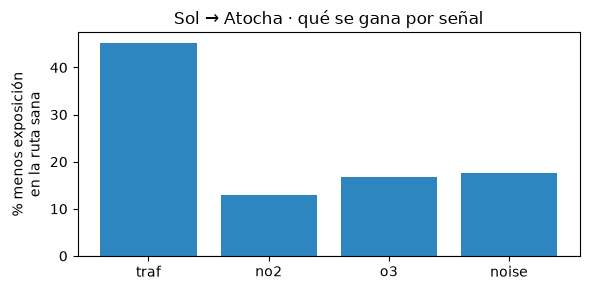

In [6]:
import matplotlib.pyplot as plt

r = tools.ruta_saludable("Sol", "Atocha", "asma_epoc", MOMENTO)
assert r.disponible, r.motivo
s, f = r.ruta_sana, r.ruta_rapida
print(f"Sol → Atocha  ·  perfil {r.perfil}  ·  {r.dia} {r.hora}:00")
print(f"  ruta rápida:  {f.dist_m:>7.0f} m   ({f.n_nodos} nodos)")
print(f"  ruta sana:    {s.dist_m:>7.0f} m   ({s.n_nodos} nodos)   "
      f"+{r.delta_distancia_pct:.1f}% de distancia")
print(f"  exposición ponderada evitada: {r.reduccion_exposicion_pct:.0f}%")
print(f"  cambio por señal (+ = la sana expone menos): {r.cambio_exposicion_pct}")
print(f"  mejor hora de salida hoy: {r.mejor_hora_salida}:00")

señales = list(r.cambio_exposicion_pct)
vals = [r.cambio_exposicion_pct[k] for k in señales]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(señales, vals, color=["#2e86c1" if v >= 0 else "#c0392b" for v in vals])
ax.axhline(0, color="0.4", lw=0.8)
ax.set_ylabel("% menos exposición\nen la ruta sana"); ax.set_title("Sol → Atocha · qué se gana por señal")
plt.tight_layout(); plt.show()


In [7]:
# el mismo destino, tres perfiles: cuánto se desvía cada uno
for perfil in ("general", "ciclista", "asma_epoc"):
    rp = tools.ruta_saludable("Moncloa", "Retiro", perfil, MOMENTO)
    print(f"  {perfil:12}  +{rp.delta_distancia_pct:4.1f}% distancia   "
          f"−{rp.reduccion_exposicion_pct:4.0f}% exposición   salir a las {rp.mejor_hora_salida}:00")


  general       + 4.0% distancia   −  13% exposición   salir a las 5:00


  ciclista      + 4.0% distancia   −  13% exposición   salir a las 5:00


  asma_epoc     + 4.0% distancia   −  13% exposición   salir a las 6:00


## 5 · Degradación elegante — el asistente no se lo inventa

`ruta_saludable` solo enruta entre **17 puntos de referencia**. Un lugar que
no reconoce → `disponible=False` + un `motivo` que lo nombra y lista las
opciones válidas. El `_SYSTEM_PROMPT` del chat (endurecido en el fix de
rutas) obliga al modelo a **decir el motivo y ofrecer las opciones**, nunca
a fabricar una ruta.


In [8]:
bad = tools.ruta_saludable("Vallecas", "Chamberí", "sensible_aire")
print("ruta_saludable('Vallecas', 'Chamberí'):")
print("  disponible =", bad.disponible)
print("  motivo     =", bad.motivo)
print("  lugares_disponibles =", ", ".join(bad.lugares_disponibles))

# y lo que hace el prompt con eso (extracto de las reglas que recibe el LLM)
reglas = [l.strip() for l in chat._SYSTEM_PROMPT.split(".") if "disponible" in l.lower() or "inventes" in l.lower()]
print("\nreglas del sistema relevantes:")
for x in reglas:
    print("  ·", x.strip())


ruta_saludable('Vallecas', 'Chamberí'):
  disponible = False
  motivo     = no reconozco «Vallecas» como origen. Solo puedo enrutar entre estos puntos de referencia: Atocha, Bernabéu, Callao, Chamartín, Cibeles, Gran Vía, Gregorio Marañón, Legazpi, Metropolitano, Moncloa, Nuevos Ministerios, Plaza Castilla, Plaza Elíptica, Príncipe Pío, Retiro, Sol, Ventas
  lugares_disponibles = Atocha, Bernabéu, Callao, Chamartín, Cibeles, Gran Vía, Gregorio Marañón, Legazpi, Metropolitano, Moncloa, Nuevos Ministerios, Plaza Castilla, Plaza Elíptica, Príncipe Pío, Retiro, Sol, Ventas

reglas del sistema relevantes:
  · Basas cada respuesta únicamente en lo que devuelven las herramientas -- nunca inventes una cifra, una estación ni una ruta que no aparezca en el resultado
  · Cada herramienta devuelve un objeto con `disponible` y, si algo falla, un `motivo`
  · Si `disponible` es false: NO te inventes el resultado; di el `motivo` con tus palabras y, si el objeto trae una lista de opciones válidas (`lu

## 6 · Cómo lo ve el usuario, y dónde probarlo

**Landing** (`web/index.html`, S3/CloudFront) — login demo, chat a pantalla
completa. Cada respuesta lleva la traza ` …` de §3; el botón
**«? Qué puedo preguntar»** despliega el catálogo de §1.

**Mapa animado** (`viz/mapa/`, servido en `/mapa` y en GitHub Pages) — 24 h
de Madrid hora a hora sobre el grafo, con el mismo asistente en el panel
lateral (mismo `/chat`, mismo origen).

**Explorador de grafo en vivo** (`viz/grafo_explorador_live.html`) — el
grafo real de Neo4j (~9.600 nodos): vecindario, centralidad, resiliencia,
rutas, y un chat que refleja lo que menciona sobre el propio grafo.

| Componente | Dónde |
|---|---|
| Landing + chat | la URL de CloudFront del despliegue (auth demo/demo) |
| Mapa animado | `https://madrono-ucm.github.io/madronoTFM/` · o `/mapa` en la EC2 |
| API + `/chat` + `/chat/catalogo` | la EC2 detrás de nginx (Basic auth) |
| Servidor MCP | `/mcp-server` (streamable-http) — cliente MCP real, ver `doc/VIKT-06` |


## 7 · Honestidad (memoria §7.4)

- **Ventana de datos corta**: los modelos que alimentan las tools `*_prevista`
  y la exposición de `ruta_saludable` son una *demostración de metodología*.
  `fiabilidad` nunca pasa de «media» (y en rutas está topada en «baja»).
- **Pipeline congelado** desde 2026-08-30: si se pide un momento posterior,
  se usa la última hora con lectura real. El asistente lo dice.
- **`ruta_saludable`**: 3 días curados de agosto 2026, 17 puntos de
  referencia. El O₃ (regional) apenas se esquiva.
- Los índices/niveles («buena», «fluido», …) son etiquetas **simplificadas**,
  no el ICA oficial.

### Recap

| capa | evidencia aquí |
|---|---|
| MCP | §1 — 19 tools read-only desde un registro único, + catálogo del chat |
| envoltorio | §2 — `{disponible, motivo, datos}`, honesto cuando no hay datos |
| **orquestación** | §3 — bucle de tool-calling real + traza `pasos` (FIL_95) |
| producto | §4 — `ruta_saludable`: sana vs rápida, 9 perfiles, mejor hora |
| rigor | §5 — no inventa: dice el motivo y ofrece opciones |

Demo de ML (STGNN, importancia de aristas): `notebooks/demo_madrono.ipynb`.
Recorrido con comandos reales: `doc/VIKT-06-recorrido-e2e.md`.
